<a href="https://colab.research.google.com/github/Akshitajhanwar/Celebal/blob/main/Assignment_4_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

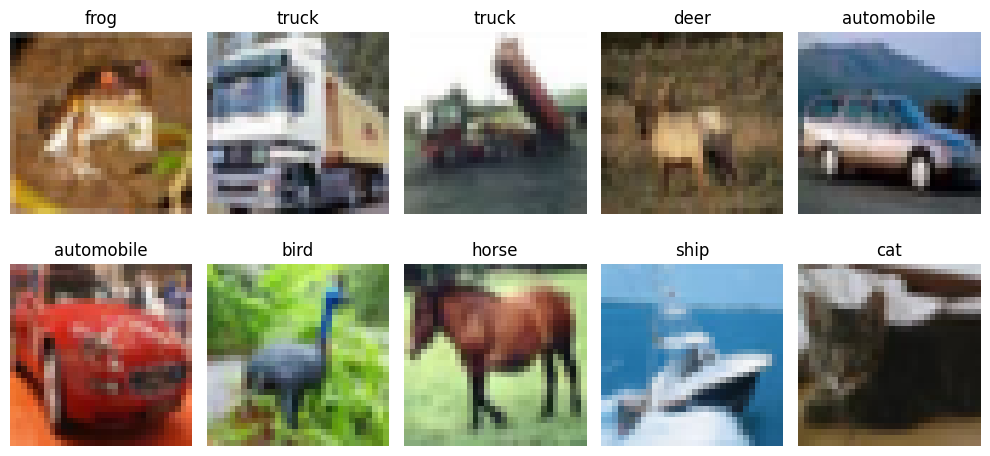

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [4]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [5]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 36ms/step - accuracy: 0.2664 - loss: 2.0083 - val_accuracy: 0.3138 - val_loss: 1.9010
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 36ms/step - accuracy: 0.3175 - loss: 1.8733 - val_accuracy: 0.3596 - val_loss: 1.7813
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 37s 30ms/step - accuracy: 0.3364 - loss: 1.8235 - val_accuracy: 0.3858 - val_loss: 1.7332
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3517 - loss: 1.7858 - val_accuracy: 0.3894 - val_loss: 1.7235
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.3657 - loss: 1.7541 - val_accuracy: 0.3820 - val_loss: 1.7425
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 35ms/step - accuracy: 0.3703 - loss: 1.7384 - val_accuracy: 0.4036 - val_loss: 1.7120
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3747 - loss: 1.7244 - val_accuracy: 0.4088 - val_loss: 1.7004
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.3795 - loss: 1.7062 - 

In [6]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4237 - loss: 1.6440
ANN Test Accuracy: 0.4237000048160553


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [7]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 90s 123ms/step - accuracy: 0.4722 - loss: 1.4838 - val_accuracy: 0.5410 - val_loss: 1.2726
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 88s 125ms/step - accuracy: 0.6072 - loss: 1.1251 - val_accuracy: 0.5310 - val_loss: 1.3679
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 89s 126ms/step - accuracy: 0.6664 - loss: 0.9583 - val_accuracy: 0.6088 - val_loss: 1.1248
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 90s 128ms/step - accuracy: 0.7075 - loss: 0.8421 - val_accuracy: 0.6102 - val_loss: 1.1498
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 126ms/step - accuracy: 0.7407 - loss: 0.7482 - val_accuracy: 0.6690 - val_loss: 0.9679
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 140s 124ms/step - accuracy: 0.7655 - loss: 0.6682 - val_accuracy: 0.6874 - val_loss: 0.9370
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 123ms/step - accuracy: 0.7903 - loss: 0.5972 - val_accuracy: 0.6582 - val_loss: 1.0513
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 87s 123ms/step - accuracy: 0.8114 - loss

In [8]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.6962 - loss: 0.9864
CNN Test Accuracy: 0.6962000131607056


## 📈 Compare Learning Curves

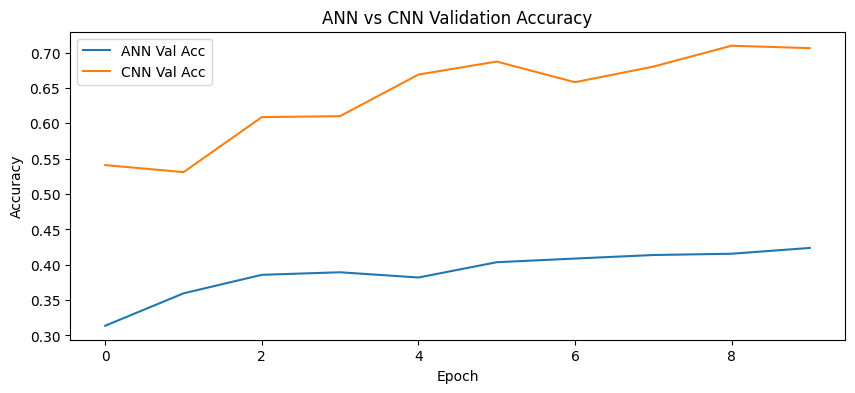

In [9]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [10]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

# 📊 Final Comparison Table

In [11]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4237
1,CNN,0.6962


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

## Implementing Student Learning Tasks

### Task 1 & 3 & 4: Increase ANN layers, Increase epochs to 20, Add EarlyStopping

In [ ]:
# Define EarlyStopping callback
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True
)

# ANN Model with increased layers
ann_model_v2 = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'), # Added layer
    layers.Dense(128, activation='relu'), # Increased layers
    layers.Dense(10, activation='softmax')
])

ann_model_v2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Training ANN Model V2 (more layers, 20 epochs, EarlyStopping)...")
ann_history_v2 = ann_model_v2.fit(
    x_train_flat, y_train,
    epochs=20, # Increased epochs
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stopping] # Added EarlyStopping
)

ann_test_loss_v2, ann_test_acc_v2 = ann_model_v2.evaluate(x_test_flat, y_test)
print("ANN Model V2 Test Accuracy:", ann_test_acc_v2)

### Task 2 & 3 & 4: CNN filters (already 32, 64, 128), Increase epochs to 20, Add EarlyStopping

In [ ]:
# CNN Model with 20 epochs and EarlyStopping (filters are already 32,64,128 in the original CNN setup)
cnn_model_v2 = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model_v2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Training CNN Model V2 (20 epochs, EarlyStopping)...")
cnn_history_v2 = cnn_model_v2.fit(
    x_train_norm, y_train,
    epochs=20, # Increased epochs
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stopping] # Added EarlyStopping
)

cnn_test_loss_v2, cnn_test_acc_v2 = cnn_model_v2.evaluate(x_test_norm, y_test)
print("CNN Model V2 Test Accuracy:", cnn_test_acc_v2)

### Task 5 & 3 & 4: Add Data Augmentation Training, Increase epochs to 20, Add EarlyStopping

In [ ]:
# Data Augmentation CNN Model with 20 epochs and EarlyStopping
# Reusing the data_augmentation and aug_cnn_model structure from previous cell

# Ensure data_augmentation and aug_cnn_model are defined if this cell is run independently
# (Assuming they are defined in previous executed cells)

aug_cnn_model_v2 = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model_v2.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

print("Training Augmented CNN Model (20 epochs, EarlyStopping)...")
aug_history = aug_cnn_model_v2.fit(
    x_train_norm, y_train,
    epochs=20, # Increased epochs
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stopping] # Added EarlyStopping
)

aug_test_loss, aug_test_acc = aug_cnn_model_v2.evaluate(x_test_norm, y_test)
print("Augmented CNN Model Test Accuracy:", aug_test_acc)

## Updated Comparison of Learning Curves

NameError: name 'ann_history_v2' is not defined

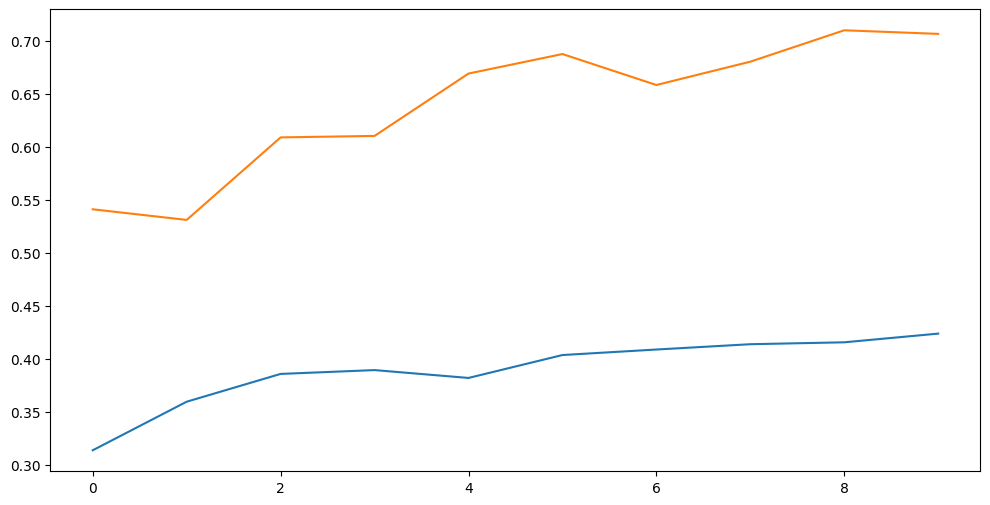

In [12]:
plt.figure(figsize=(12, 6))
plt.plot(ann_history.history['val_accuracy'], label='Original ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='Original CNN Val Acc')
plt.plot(ann_history_v2.history['val_accuracy'], label='ANN V2 Val Acc (More Layers, ES, 20E)')
plt.plot(cnn_history_v2.history['val_accuracy'], label='CNN V2 Val Acc (ES, 20E)')
plt.plot(aug_history.history['val_accuracy'], label='Augmented CNN Val Acc (ES, 20E)')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model Validation Accuracy Comparison")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(ann_history.history['val_loss'], label='Original ANN Val Loss')
plt.plot(cnn_history.history['val_loss'], label='Original CNN Val Loss')
plt.plot(ann_history_v2.history['val_loss'], label='ANN V2 Val Loss (More Layers, ES, 20E)')
plt.plot(cnn_history_v2.history['val_loss'], label='CNN V2 Val Loss (ES, 20E)')
plt.plot(aug_history.history['val_loss'], label='Augmented CNN Val Loss (ES, 20E)')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Model Validation Loss Comparison")
plt.legend()
plt.grid(True)
plt.show()

## Final Comparison Table (Including new models)

In [13]:
comparison_v2 = pd.DataFrame({
    "Model": ["Original ANN", "Original CNN", "ANN V2 (More Layers, ES, 20E)", "CNN V2 (ES, 20E)", "Augmented CNN (ES, 20E)"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc, ann_test_acc_v2, cnn_test_acc_v2, aug_test_acc]
})
display(comparison_v2)

NameError: name 'ann_test_acc_v2' is not defined

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**